In [7]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict


In [29]:
# define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [30]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state


In [31]:
def bmi_category(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        category = 'Underweight'
    elif bmi < 25:
        category = 'Normal weight'
    elif bmi < 30:
        category = 'Overweight'
    else:
        category = 'Obesity'

    state['category'] = category

    return state

In [32]:
# define graph
graph = StateGraph(BMIState)

# add nodes to graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('bmi_category', bmi_category)

# add edges to graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'bmi_category')
graph.add_edge('bmi_category', END)

# compile the graph
workflow = graph.compile()



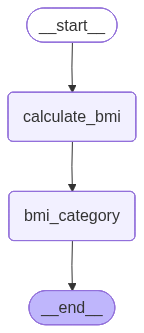

In [33]:
workflow

In [37]:
# execute the graph
initial_state = {'weight_kg': 70, 'height_m': 1.70}

final_state = workflow.invoke(initial_state)

print(final_state)
# workflow.invoke({'weight_kg': 70, 'height_m': 1.70})

{'weight_kg': 70, 'height_m': 1.7, 'bmi': 24.22, 'category': 'Normal weight'}
